In [1]:
import torch
i = 10
A = torch.load(f'/home/sz3684/diffusion/flux_svd_iccv/tensors/A/A_{i}.pt')
dst = torch.load(f'/home/sz3684/diffusion/flux_svd_iccv/tensors/dst/dst_{i}.pt')
dst_idx = torch.load(f'/home/sz3684/diffusion/flux_svd_iccv/tensors/dst_idx/dst_idx_{i}.pt')
x = torch.load(f'/home/sz3684/diffusion/flux_svd_iccv/tensors/x/x_{i}.pt')

x = x / x.norm(dim=-1, keepdim=True)
dst = dst / dst.norm(dim=-1, keepdim=True)

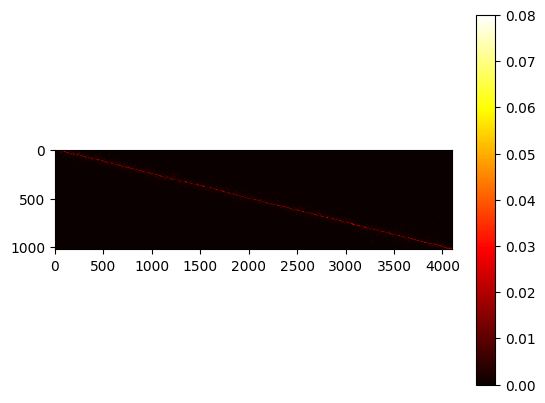

In [2]:
#Normalize A_k
import torch.nn.functional as F
import matplotlib.pyplot as plt
original_matrix = A[0]
plt.imshow(original_matrix.float().cpu().detach().numpy(), cmap='hot', vmin=0, vmax=8e-2)
plt.colorbar() 
plt.show()

In [3]:
largest_numbers = torch.max(original_matrix, dim=1)[0]
print(largest_numbers)

tensor([1.0000, 0.1904, 0.2969,  ..., 0.3809, 0.2334, 0.1787], device='cuda:0',
       dtype=torch.bfloat16)


In [4]:
sorted_rows, sorted_indices = torch.sort(original_matrix, dim=1, descending=True)

print(sorted_rows.shape)
print(sorted_indices)

torch.Size([1024, 4096])
tensor([[   0,    1, 4032,  ..., 3206, 3492, 3644],
        [   5,    2,   20,  ..., 2252, 2812, 3464],
        [   7,    1,   62,  ..., 3252, 3492, 3644],
        ...,
        [4089, 4049, 4040,  ..., 1424,  675,  821],
        [4091, 4093, 4094,  ..., 1079,  166,  470],
        [4092, 4082, 4081,  ...,  425,  606,  408]], device='cuda:0')


In [5]:
count = 0
index = 0

for row, indices in zip(sorted_rows, sorted_indices):
    index += 1
    if row[1] > 0.4:
        print(f'index for dst {dst_idx[:,index-1]}')
        print(f'index for x: {indices[:2]}')  # Print top 2 values and their original indices
        print(row[:2])
        count += 1

        index_tensor = torch.tensor([[index]], device=dst.device)  # Ensure correct shape for gather
        dst_target = torch.gather(dst, 1, index_tensor.unsqueeze(-1).repeat(1, 1, dst.shape[-1]))  # Target value

        x_1 = torch.gather(x, 1, indices[0].unsqueeze(0).expand(1, 1, x.shape[-1]))  # First index
        x_2 = torch.gather(x, 1, indices[1].unsqueeze(0).expand(1, 1, x.shape[-1]))  # Second index

        mse_x0 = torch.mean((dst_target - x_1)**2)
        mse_x1 = torch.mean((dst_target - x_2)**2)
        mse_x0_x1 = torch.mean((x_1 - x_2)**2).float()

        for i in [indices[0], indices[1]]:
            print(f'row: {i // 64}, col: {i % 64}')

        print("MSE between x_0 and x_1:", mse_x0_x1)
        print('')

print(count)


index for dst tensor([[32]], device='cuda:0')
index for x: tensor([31, 32], device='cuda:0')
tensor([0.4121, 0.4121], device='cuda:0', dtype=torch.bfloat16)
row: 0, col: 31
row: 0, col: 32
MSE between x_0 and x_1: tensor(3.9816e-05, device='cuda:0')

index for dst tensor([[111]], device='cuda:0')
index for x: tensor([110, 111], device='cuda:0')
tensor([0.4102, 0.4102], device='cuda:0', dtype=torch.bfloat16)
row: 1, col: 46
row: 1, col: 47
MSE between x_0 and x_1: tensor(6.9618e-05, device='cuda:0')

index for dst tensor([[169]], device='cuda:0')
index for x: tensor([168, 169], device='cuda:0')
tensor([0.4453, 0.4453], device='cuda:0', dtype=torch.bfloat16)
row: 2, col: 40
row: 2, col: 41
MSE between x_0 and x_1: tensor(7.0572e-05, device='cuda:0')

index for dst tensor([[234]], device='cuda:0')
index for x: tensor([234, 560], device='cuda:0')
tensor([0.5273, 0.4219], device='cuda:0', dtype=torch.bfloat16)
row: 3, col: 42
row: 8, col: 48
MSE between x_0 and x_1: tensor(0.0001, device='c

In [8]:
count = 0
threshold = 0.5  # Set your threshold here
rows_below_threshold = 0  # Counter for rows where the sum of top 10 values is below the threshold

for row, indices in zip(sorted_rows, sorted_indices):
    # Get the top 10 values and their indices
    top_values, top_indices = torch.topk(row, 3)
    
    # Compute the sum of the top 10 values
    sum_top_values = torch.sum(top_values)
    
    # If the sum of top 10 values is below the threshold, increment the count
    if sum_top_values < 0.5:
        rows_below_threshold += 1
    
        # Optionally print details of each row (can be removed if not needed)
        print(f'Top 3 values: {top_values}')
        print(f'Indices of top 3 values: {top_indices}')
        print(f'Sum of top 3 values: {sum_top_values}')
        print('')
        count += 1
# Print the number of rows where the sum of top 10 values is below the threshold
print(f'Rows with sum of top 10 values below threshold: {rows_below_threshold}')
print(f'Total rows processed: {count}')


Top 3 values: tensor([0.1904, 0.1670, 0.1357], device='cuda:0', dtype=torch.bfloat16)
Indices of top 3 values: tensor([0, 1, 2], device='cuda:0')
Sum of top 3 values: 0.4921875

Top 3 values: tensor([0.1641, 0.1641, 0.1631], device='cuda:0', dtype=torch.bfloat16)
Indices of top 3 values: tensor([1, 0, 2], device='cuda:0')
Sum of top 3 values: 0.4921875

Top 3 values: tensor([0.1631, 0.1602, 0.1572], device='cuda:0', dtype=torch.bfloat16)
Indices of top 3 values: tensor([0, 1, 2], device='cuda:0')
Sum of top 3 values: 0.48046875

Top 3 values: tensor([0.1514, 0.1426, 0.1367], device='cuda:0', dtype=torch.bfloat16)
Indices of top 3 values: tensor([0, 1, 2], device='cuda:0')
Sum of top 3 values: 0.4296875

Top 3 values: tensor([0.1309, 0.1299, 0.1299], device='cuda:0', dtype=torch.bfloat16)
Indices of top 3 values: tensor([0, 2, 1], device='cuda:0')
Sum of top 3 values: 0.390625

Top 3 values: tensor([0.1406, 0.0845, 0.0767], device='cuda:0', dtype=torch.bfloat16)
Indices of top 3 values: